In [1]:
import pandas as pd
import re
import math
import cartopy.crs as ccrs
import cartopy
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import statsmodels.api as sm
import geopandas as gpd
from scipy import stats
import datetime
import seaborn as sns
from geopy.distance import distance
import geopandas as gpd
import rioxarray
from functools import reduce
import warnings
warnings.filterwarnings('ignore')

In [2]:
def detrend(ts):

    for i in range(len(ts)):
        if np.isnan(ts[i]):
            ts[i] = np.nanmean(ts)
            
    X = np.array([[1,i] for i in range(len(ts))])
    y = np.array(ts)
    
    ols = sm.OLS(y, X, missing = 'drop')
    ols_model = ols.fit()

    fit = ols_model.predict()

    new_ts = []
    for i in range(len(ts)):
        new_ts.append(ts[i] - (fit[i]-ts[0]))
    
    #plt.plot(y)
    #plt.plot(new_ts)
    #plt.plot(fit)
    
    return new_ts


In [3]:
# load ERA5 data

# extended study area to include Tasmania for M1
monthly_msl_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/M1_range_mslp/1969_2019.nc')

# NZ only study area data
monthly_misc = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/1969_2019_all.nc')
monthly_snowmelt = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/snow/snowmelt/1969_2019.nc')
monthly_runoff = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/runoff/total_runoff/1969_2019.nc')
monthly_snow = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/snow/1959_2021.nc')
monthly_temp = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/temp/1959_2019.nc')

monthly_era = xr.merge([monthly_misc,monthly_snowmelt,monthly_runoff,monthly_snow,monthly_temp])
seasonal_era = monthly_era.resample(time='Q-DEC').mean()

# interpolate ERA5 to finer spatial resolution
new_lon = np.linspace(seasonal_era.longitude[0], seasonal_era.longitude[-1], len(seasonal_era.longitude.values) * 10)
new_lat = np.linspace(seasonal_era.latitude[0], seasonal_era.latitude[-1], len(seasonal_era.latitude.values) * 10)

monthly_era_interp = monthly_era.interp(latitude=new_lat, longitude=new_lon,method='linear').sel(time=slice('1969', '2019'))
seasonal_era_interp = seasonal_era.interp(latitude=new_lat, longitude=new_lon,method='linear').sel(time=slice('1969', '2019'))

# load MONTHLY observed flow data
flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/daily/50yrs/full_records.csv')
flow_df.Date = pd.to_datetime(flow_df.Date)
flow_df.set_index('Date', inplace=True)
flow_df = flow_df['1969':'2019']
monthly_flow_df = flow_df.resample('M').mean()
monthly_flow_df.index=monthly_flow_df.index.map(lambda x : x.replace(day=1))
#monthly_flow_df.fillna(monthly_flow_df.mean(), inplace=True)

# load SEASONAL observed flow data
seasonal_flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/new_full_records.csv')
seasonal_flow_df.date = pd.to_datetime(seasonal_flow_df.date)
seasonal_flow_df.set_index('date', inplace=True)
seasonal_flow_df = seasonal_flow_df['1969':'2019'] 

# load metadata
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)
subset_meta = metadata_df.loc[[int(s) for s in seasonal_flow_df.columns]]
subset_meta.sort_values('gauge_lat', ascending = False, inplace=True)
subset_meta['number_label'] = np.arange(1,len(subset_meta)+1)
subset_meta['number_copy'] = subset_meta.index.values.tolist()
meta_df = gpd.GeoDataFrame(subset_meta,geometry=gpd.points_from_xy(x=subset_meta.gauge_lon, y=subset_meta.gauge_lat),
                          crs='EPSG:4326')

# load catchment shape data
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")
catchment_data = catchment_data.loc[catchment_data['SITE'].isin(seasonal_flow_df.columns)]
catchment_data.index = catchment_data['SITE']

In [48]:
monthly_era

<xarray.Dataset>
Dimensions:    (latitude: 61, longitude: 61, time: 756)
Coordinates:
  * time       (time) datetime64[ns] 1959-01-01 1959-02-01 ... 2021-12-01
  * longitude  (longitude) float32 165.0 165.25 165.5 ... 179.5 179.75 180.0
  * latitude   (latitude) float32 -33.0 -33.25 -33.5 ... -47.5 -47.75 -48.0
Data variables:
    msl        (time, latitude, longitude) float32 nan nan nan ... nan nan nan
    tcrw       (time, latitude, longitude) float32 nan nan nan ... nan nan nan
    tcsw       (time, latitude, longitude) float32 nan nan nan ... nan nan nan
    tp         (time, latitude, longitude) float32 nan nan nan ... nan nan nan
    sro        (time, latitude, longitude) float32 nan nan nan ... nan nan nan
    smlt       (time, latitude, longitude) float32 nan nan nan ... nan nan nan
    ro         (time, latitude, longitude) float32 nan nan nan ... nan nan nan
    sd         (time, latitude, longitude) float32 ...
    sf         (time, latitude, longitude) float32 ...
    t2m        (time, latitude, longitude) float32 294.67114 294.63022 ... nan

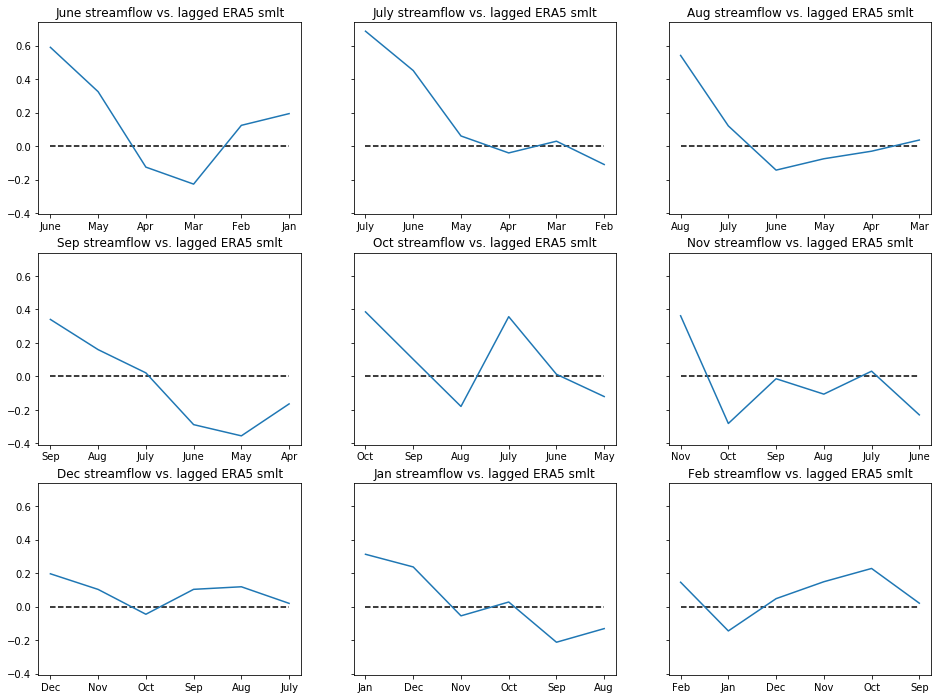

In [148]:
'''
OBS streamflow Vs. ERA5 Snowmelt lag correlations
'''

fig, axs = plt.subplots(3,3,figsize=(16,12),sharey=True)
axs = axs.flatten()

month_dict = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'June',7:'July',8:'Aug',
               9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

index = 'smlt'
era_da = monthly_era_interp[index].rio.write_crs("EPSG:4326")
era_da.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

for i,month in enumerate([6,7,8,9,10,11,12,1,2]):
    
    #month = i+1
        
    for site in ['71120']:#,'71123','71132','75292','71129','71135']:

        ob_flow = monthly_flow_df[site]
        ob_month = ob_flow[ob_flow.index.month == month]
        detrended_obs = detrend(ob_month)

        catchment_geo = catchment_data.loc[[float(site)]]

        clipped = era_da.rio.clip(catchment_geo.geometry,catchment_data.crs)
        clipped_era = clipped.mean(['longitude','latitude'])

        vals = []
        comp_months = []
        for j in range(6):
            if j >= month:
                comp_month = 12 - (j - month)
                comp_month_ts = clipped_era.sel(time=clipped_era.time.dt.month.isin([comp_month])).values.tolist()
                
                obs_ts = detrended_obs[1:]
                comp_month_ts = comp_month_ts[:-1]

            else:
                comp_month = month - j
                comp_month_ts = clipped_era.sel(time=clipped_era.time.dt.month.isin([comp_month])).values.tolist()
                obs_ts = detrended_obs
                
            #print(str(month) + 'v ' + str(comp_month))
            #print(str(ob_month.index.year[0]) + " " +  str(ob_month.index.month[0]))
            #print(str(ERA5_month.index.year[0]) + " " +  str(ERA5_month.index.month[0]))
            
            (r,p) = stats.pearsonr(obs_ts,comp_month_ts)

            comp_months.append(month_dict[comp_month])
            vals.append(r)

        axs[i].plot(vals)
        axs[i].set_xticks([k for k in range(len(vals))])
        axs[i].set_xticklabels(comp_months)
        axs[i].hlines(0,0,5,'black','dashed')

    axs[i].set_title(month_dict[month] + " streamflow vs. lagged ERA5 " + index)

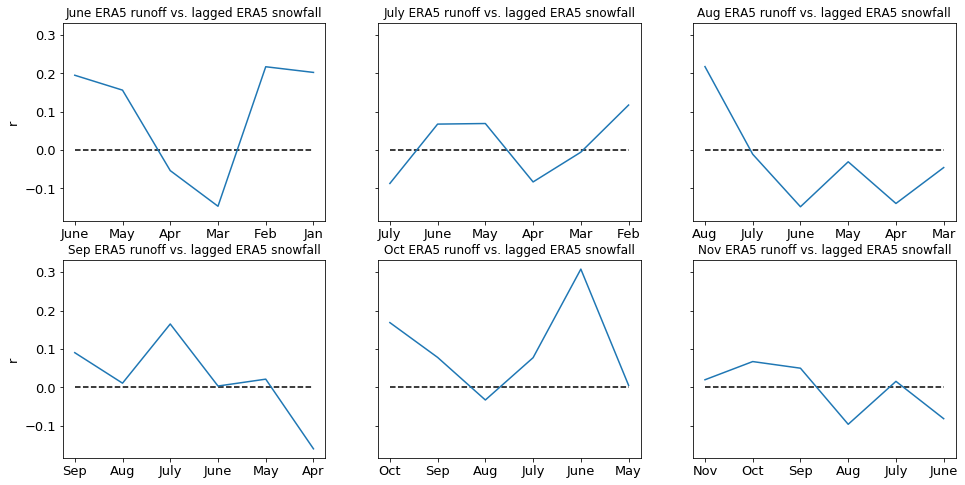

In [53]:
'''
ERA5 Runoff Vs. Snowmelt lag correlations
'''

fig, axs = plt.subplots(2,3,figsize=(16,8),sharey=True)
axs = axs.flatten()

month_dict = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'June',7:'July',8:'Aug',
              9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

index_1 = 'ro'
era_1 = monthly_era_interp[index_1].rio.write_crs("EPSG:4326")
era_1.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

index_2 = 'sf'
era_2 = monthly_era_interp[index_2].rio.write_crs("EPSG:4326")
era_2.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

for site in ['71132',]:#,'71123','71120','75292','71129','71135']:
    
    catchment_geometry = catchment_data.loc[[float(site)]]

    masked_era_1 = era_1.rio.clip(catchment_geometry.geometry,catchment_data.crs).mean(['longitude','latitude'])
    masked_era_2 = era_2.rio.clip(catchment_geometry.geometry,catchment_data.crs).mean(['longitude','latitude'])

    for i,month in enumerate([6,7,8,9,10,11]):
            
        era_1_month = masked_era_1.sel(time=masked_era_1.time.dt.month.isin([month]))
        #era_1_detrended = detrend(era_1_month.values.tolist())
        
        r_vals = []
        comp_months = []
        for j in range(6):
            
            if j >= month:
                comp_month = 12 - (j - month)
                era_2_month = masked_era_2.sel(time=masked_era_2.time.dt.month.isin([comp_month])).values.tolist()
                #era_2_detrended = detrend(era_2_month)
                
                era_1_ts = era_1_month[1:]
                era_2_ts = era_2_month[:-1]

            else:
                comp_month = month - j
                
                era_2_month = masked_era_2.sel(time=masked_era_2.time.dt.month.isin([comp_month])).values.tolist()
                #era_2_detrended = detrend(era_2_month)
                
                era_1_ts = era_1_month
                era_2_ts = era_2_month
                
            (r,p) = stats.pearsonr(era_1_ts,era_2_ts)

            comp_months.append(month_dict[comp_month])
            r_vals.append(r)

        axs[i].plot(r_vals)
        axs[i].set_xticks([k for k in range(len(r_vals))])
        axs[i].set_xticklabels(comp_months)
        axs[i].hlines(0,0,5,'black','dashed')

        axs[i].set_title(month_dict[month] + " ERA5 runoff vs. lagged ERA5 snowfall")
        
axs[0].set_ylabel('r',fontsize=13)
axs[3].set_ylabel('r',fontsize=13)

for ax in axs:
    ax.tick_params(axis='y',labelsize=13)
    ax.tick_params(axis='x',labelsize=13)

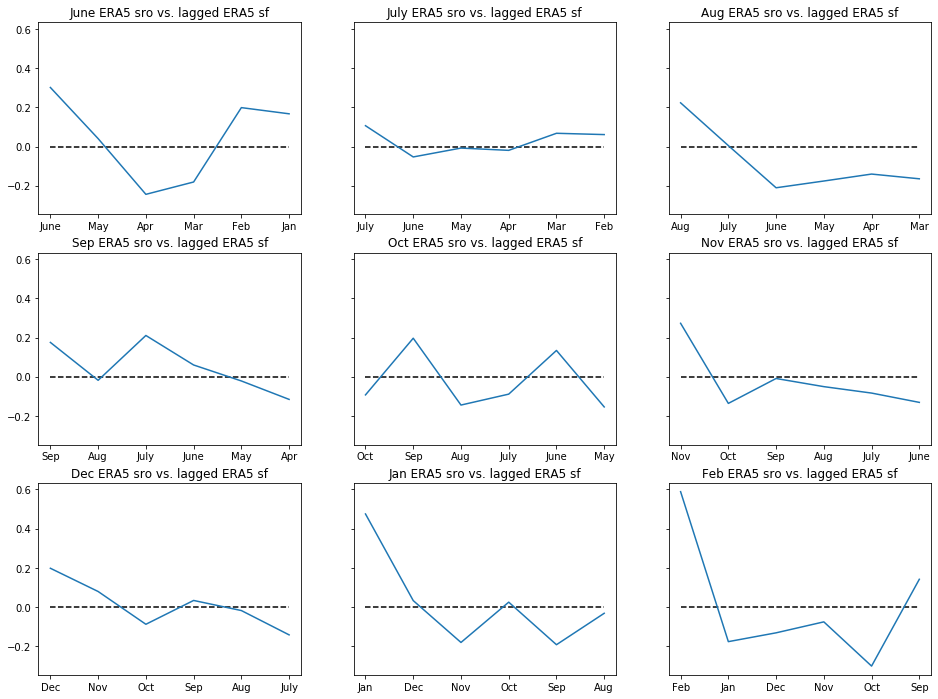

In [145]:
'''
ERA5 Runoff Vs. Snowmelt lag correlations
'''

fig, axs = plt.subplots(3,3,figsize=(16,12),sharey=True)
axs = axs.flatten()

month_dict = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'June',7:'July',8:'Aug',
              9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

index_1 = 'sro'
era_1 = monthly_era_interp[index_1].rio.write_crs("EPSG:4326")
era_1.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

index_2 = 'sf'
era_2 = monthly_era_interp[index_2].rio.write_crs("EPSG:4326")
era_2.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

for site in ['71132',]:#,'71123','71120','75292','71129','71135']:
    
    catchment_geometry = catchment_data.loc[[float(site)]]

    masked_era_1 = era_1.rio.clip(catchment_geometry.geometry,catchment_data.crs).mean(['longitude','latitude'])
    masked_era_2 = era_2.rio.clip(catchment_geometry.geometry,catchment_data.crs).mean(['longitude','latitude'])

    for i,month in enumerate([6,7,8,9,10,11,12,1,2]):
            
        era_1_month = masked_era_1.sel(time=masked_era_1.time.dt.month.isin([month]))
        #era_1_detrended = detrend(era_1_month.values.tolist())
        
        r_vals = []
        comp_months = []
        for j in range(6):
            
            if j >= month:
                comp_month = 12 - (j - month)
                era_2_month = masked_era_2.sel(time=masked_era_2.time.dt.month.isin([comp_month])).values.tolist()
                #era_2_detrended = detrend(era_2_month)
                
                era_1_ts = era_1_month[1:]
                era_2_ts = era_2_month[:-1]

            else:
                comp_month = month - j
                
                era_2_month = masked_era_2.sel(time=masked_era_2.time.dt.month.isin([comp_month])).values.tolist()
                #era_2_detrended = detrend(era_2_month)
                
                era_1_ts = era_1_month
                era_2_ts = era_2_month
                
            (r,p) = stats.pearsonr(era_1_ts,era_2_ts)

            comp_months.append(month_dict[comp_month])
            r_vals.append(r)

        axs[i].plot(r_vals)
        axs[i].set_xticks([k for k in range(len(r_vals))])
        axs[i].set_xticklabels(comp_months)
        axs[i].hlines(0,0,5,'black','dashed')

        axs[i].set_title(month_dict[month] + " ERA5 sro vs. lagged ERA5 sf")

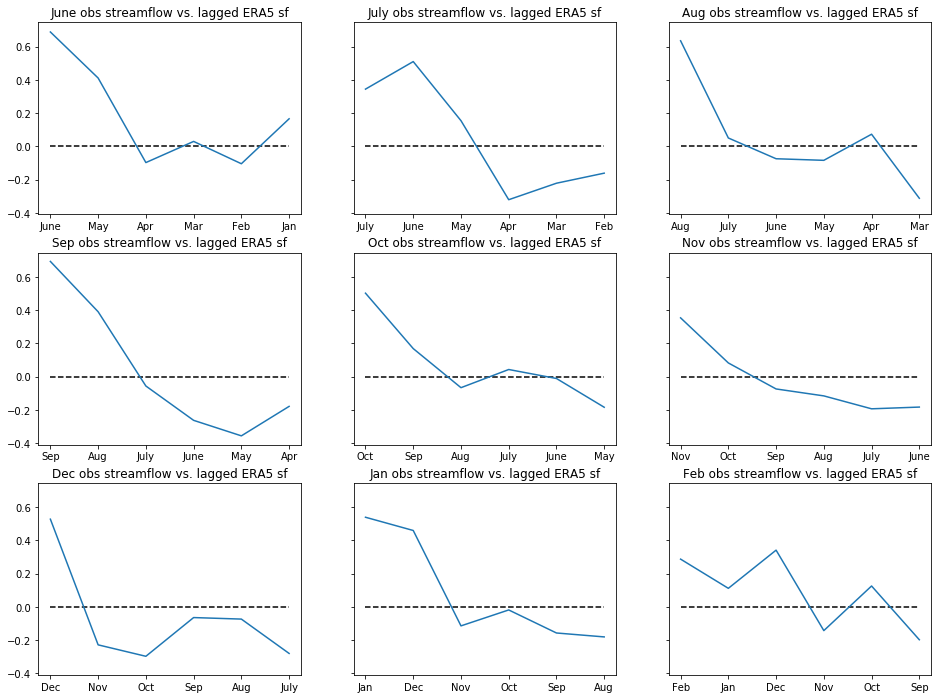

In [147]:
'''
ERA5 Runoff Vs. Snowmelt lag correlations
'''

fig, axs = plt.subplots(3,3,figsize=(16,12),sharey=True)
axs = axs.flatten()

month_dict = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'June',7:'July',8:'Aug',
              9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

index_1 = 'sro'
era_1 = monthly_era_interp[index_1].rio.write_crs("EPSG:4326")
era_1.rio.set_spatial_dims('longitude', 'latitude', inplace=True)


catchment_geometry = catchment_data.loc[[float(x) for x in ['71132','71123','71120','75292','71129','71135']]]

masked_era_1 = era_1.rio.clip(catchment_geometry.geometry,catchment_data.crs).mean(['longitude','latitude'])

for i,month in enumerate([6,7,8,9,10,11,12,1,2]):

    obs_region = monthly_flow_df[['71132','71123','71120','75292','71129','71135']].mean(axis=1)
    ob_flow_month = obs_region[obs_region.index.month == month]

    r_vals = []
    comp_months = []
    for j in range(6):

        if j >= month:
            comp_month = 12 - (j - month)
            era_1_month = masked_era_1.sel(time=masked_era_1.time.dt.month.isin([comp_month])).values.tolist()
            #era_2_detrended = detrend(era_2_month)

            era_1_ts = era_1_month[:-1]
            ob_flow_ts = ob_flow_month[1:]
        else:
            comp_month = month - j

            era_1_month = masked_era_1.sel(time=masked_era_1.time.dt.month.isin([comp_month])).values.tolist()
            #era_2_detrended = detrend(era_2_month)

            era_1_ts = era_1_month
            ob_flow_ts = ob_flow_month

        (r,p) = stats.pearsonr(ob_flow_ts,era_1_ts)

        comp_months.append(month_dict[comp_month])
        r_vals.append(r)

    axs[i].plot(r_vals)
    axs[i].set_xticks([k for k in range(len(r_vals))])
    axs[i].set_xticklabels(comp_months)
    axs[i].hlines(0,0,5,'black','dashed')

    axs[i].set_title(month_dict[month] + " obs streamflow vs. lagged ERA5 sf")

In [4]:
era_smlt = monthly_era_interp['smlt'].rio.write_crs("EPSG:4326")
era_smlt.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

era_sf = monthly_era_interp['sf'].rio.write_crs("EPSG:4326")
era_sf.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

era_sd = monthly_era_interp['sd'].rio.write_crs("EPSG:4326")
era_sd.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

era_tp = monthly_era_interp['tp'].rio.write_crs("EPSG:4326")
era_tp.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

era_ro = monthly_era_interp['ro'].rio.write_crs("EPSG:4326")
era_ro.rio.set_spatial_dims('longitude', 'latitude', inplace=True)


<xarray.DataArray 'ro' (time: 612, latitude: 610, longitude: 610)>
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])
Coordinates:
  * time         (time) datetime64[ns] 1969-01-01 1969-02-01 ... 2019-12-01
  * latitude     (latitude) float64 -33.0 -33.02 -33.05 ... -47.95 -47.98 -48.0
  * longitude    (longitude) float64 165.0 165.0 165.0 ... 180.0 180.0 180.0
    spatial_ref  int64 0
Attributes:
    units:         m
    long_name:     Runoff
    grid_mapping:  spatial_ref

(-47, -34)

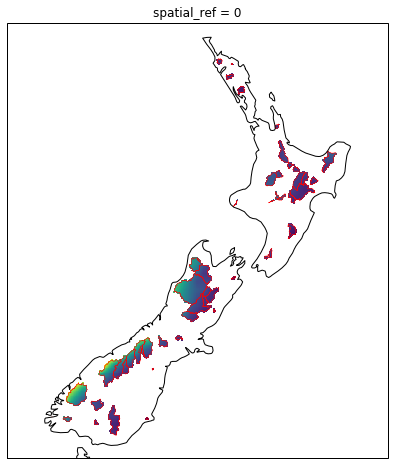

In [89]:
#data_crs = catchment_data.crs
crs = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(14,8),subplot_kw={'projection': crs})

era_tp.rio.clip(catchment_data.geometry,catchment_data.crs).mean('time').plot.pcolormesh(ax=ax, add_colorbar=False)
catchment_data.plot(ax=ax,color='',edgecolor='red',linewidth=0.4,alpha=1)

ax.coastlines(resolution='50m', color='black', linewidth=1, alpha=1)

ax.set_xlim(165,180)
ax.set_ylim(-47,-34)


In [5]:
catchment_geometry = catchment_data.loc[[float(x) for x in ['71132','71123','71120','75292','71129','71135']]]

era_smlt = era_smlt.rio.clip(catchment_geometry.geometry,catchment_data.crs).mean(['longitude','latitude'])
era_sf = era_sf.rio.clip(catchment_geometry.geometry,catchment_data.crs).mean(['longitude','latitude'])
era_sd = era_sd.rio.clip(catchment_geometry.geometry,catchment_data.crs).mean(['longitude','latitude'])
era_tp = era_tp.rio.clip(catchment_geometry.geometry,catchment_data.crs).mean(['longitude','latitude'])
era_ro = era_ro.rio.clip(catchment_geometry.geometry,catchment_data.crs).mean(['longitude','latitude'])


In [6]:
era_smlt

<xarray.DataArray 'smlt' (time: 612)>
array([1.36783626e-03, 2.48480955e-06, 1.43118932e-04, 1.64319606e-03,
       1.34232510e-03, 5.22508549e-04, 1.76466251e-03, 3.13009056e-03,
       1.17204280e-02, 4.98122989e-03, 1.59560843e-03, 8.21841059e-05,
       5.20440057e-06, 6.67753364e-05, 3.73316882e-05, 5.16613122e-04,
       2.00872288e-04, 1.57053613e-03, 2.38044210e-03, 8.49054119e-03,
       7.84049114e-03, 9.42467352e-03, 7.80817761e-03, 2.90122829e-04,
       4.78899834e-05, 2.42784517e-06, 6.79697748e-05, 8.20721367e-04,
       1.75665163e-03, 4.07148068e-03, 5.15615537e-04, 4.43781538e-03,
       5.49989355e-03, 1.23179409e-02, 6.40584600e-03, 1.28939308e-05,
       1.93351333e-05, 4.56527062e-06, 2.40402225e-04, 1.48430737e-03,
       1.90329228e-03, 7.56260197e-04, 1.98837013e-03, 2.03394386e-03,
       1.19078707e-02, 9.26468740e-03, 5.79923135e-03, 8.48585407e-04,
       1.94076740e-04, 9.31322575e-10, 3.03246404e-05, 3.42983771e-03,
       2.74706442e-03, 3.62067001e-03, 1.67195956e-03, 4.04173244e-03,
       7.97710417e-03, 9.57461640e-03, 5.33078176e-03, 9.93869085e-05,
       3.28276682e-05, 2.99508657e-06, 7.98165781e-04, 6.04276114e-04,
       3.21051257e-04, 3.26185186e-03, 1.99677128e-03, 1.25817391e-03,
       1.07442171e-02, 1.24390057e-02, 2.61330100e-03, 6.63136329e-04,
       8.05263335e-05, 4.41928927e-06, 9.05791573e-04, 2.31931219e-03,
       3.26428895e-03, 2.46760900e-03, 5.04782550e-03, 7.27285714e-03,
       9.40836123e-03, 1.12899204e-02, 5.74645956e-03, 3.62729961e-04,
       1.23319736e-03, 1.13572221e-03, 1.47080478e-07, 1.99498279e-04,
       8.65670963e-03, 4.40290821e-03, 2.28158167e-03, 5.40102491e-03,
       8.04840889e-03, 9.91039987e-03, 5.58208100e-03, 1.05942034e-03,
       1.26055863e-03, 4.73010323e-05, 9.16474208e-07, 1.58238383e-03,
       4.87837893e-03, 2.99310230e-03, 1.53784499e-03, 3.34374558e-03,
       5.63899500e-03, 1.11852328e-02, 8.34143050e-03, 1.15773487e-03,
       6.98301811e-05, 9.31322575e-10, 3.84332760e-05, 5.57510436e-04,
       8.53305088e-04, 3.25990247e-04, 3.31984735e-03, 8.72469431e-03,
       1.15904160e-02, 1.07516007e-02, 7.13997615e-03, 5.88525826e-04,
       4.34535076e-05, 2.33710304e-04, 5.67157851e-04, 2.25395986e-03,
       5.56521112e-03, 3.20670840e-03, 2.29004560e-03, 2.46313692e-03,
       9.86701161e-03, 1.02909639e-02, 3.02064443e-03, 1.81056334e-03,
       1.12046011e-03, 9.07346109e-04, 4.15350744e-04, 2.42310335e-04,
       3.04517469e-03, 4.82187347e-03, 1.29818206e-03, 6.33218467e-03,
       9.26153085e-03, 1.27687608e-02, 9.25805948e-03, 3.25741219e-03,
       3.94056737e-06, 2.12538969e-06, 1.32086194e-05, 1.86280103e-03,
       1.76953002e-03, 3.71441333e-03, 1.85865992e-03, 9.76628421e-04,
       4.98527452e-03, 1.10931396e-02, 3.06210507e-03, 1.42524545e-03,
       7.97221720e-04, 5.42730045e-05, 1.71985095e-08, 3.60099622e-04,
       3.32678547e-03, 1.99249434e-03, 5.29883229e-04, 3.62196625e-03,
       5.51856565e-03, 5.63505340e-03, 7.50750104e-03, 2.71439231e-03,
       2.45512674e-03, 1.22326929e-04, 5.05733348e-04, 3.13384798e-03,
       3.24340668e-03, 2.16257275e-03, 3.09193318e-03, 3.97845003e-03,
       7.30612057e-03, 1.32302029e-02, 7.13933816e-03, 1.14827620e-03,
       1.86550377e-04, 9.31322575e-10, 2.94308581e-06, 8.44403757e-04,
       3.61882140e-03, 4.22592997e-03, 6.98085959e-03, 7.02759120e-03,
       7.51787584e-03, 1.13212308e-02, 6.41332384e-03, 1.29495868e-03,
       1.90896570e-05, 7.30435879e-06, 1.10001546e-04, 6.64944950e-04,
       1.33411048e-03, 4.94704642e-03, 4.61277538e-03, 6.64510336e-03,
       1.04105887e-02, 7.96705017e-03, 2.16316409e-03, 9.32279874e-05,
       7.21302602e-05, 6.30045805e-05, 7.07173100e-05, 4.81309919e-04,
       2.11052275e-03, 6.32352150e-03, 1.58359744e-03, 2.73866109e-03,
       8.80009515e-03, 1.35067134e-02, 6.58462438e-03, 4.17211793e-04,
       4.79995204e-04, 3.58971715e-04, 6.38742488e-04, 4.10198200e-04,
       2.53903276e-03, 4.46444786e-03, 1.37934035e-03, 6.

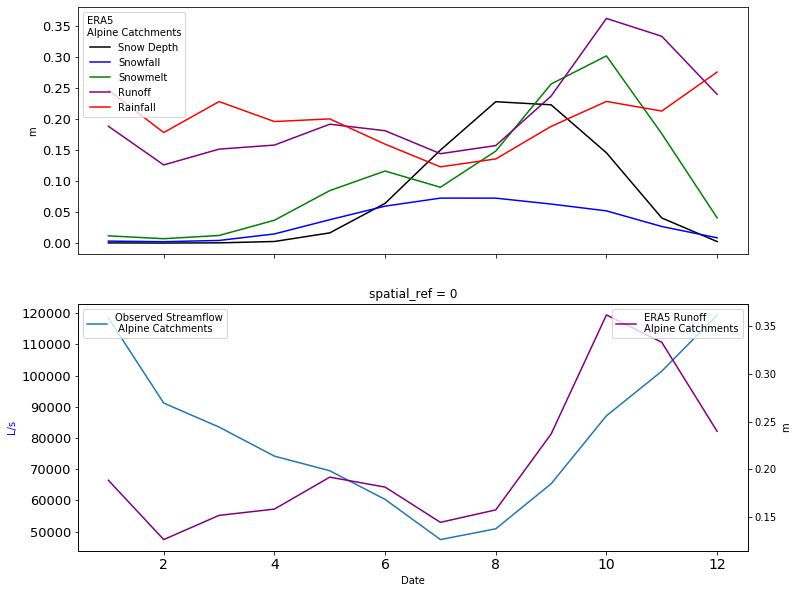

In [31]:
fig,axs = plt.subplots(2,1,figsize=(12,10),sharex=True)
axs = axs.flatten()

era_sd.groupby(era_sd.time.dt.month).mean().plot(ax=axs[0],label='Snow Depth',color='black')
(era_sf * era_sf.time.dt.daysinmonth).groupby(era_sf.time.dt.month).mean().plot(ax=axs[0],color='blue',label='Snowfall')
(era_smlt * era_smlt.time.dt.daysinmonth).groupby(era_smlt.time.dt.month).mean().plot(ax=axs[0],color='green',label='Snowmelt')
(era_ro * era_ro.time.dt.daysinmonth).groupby(era_ro.time.dt.month).mean().plot(ax=axs[0],color='purple',label='Runoff')

# rainfall, tp - sf
((era_tp * era_tp.time.dt.daysinmonth).groupby(era_tp.time.dt.month).mean() - (era_sf * era_sf.time.dt.daysinmonth).groupby(era_sf.time.dt.month).mean()).plot(ax=axs[0],color='red',label='Rainfall')

#monthly_flow_df[['71132','71123','71120','75292','71129','71135']].groupby(monthly_flow_df.index.month).mean().plot(ax=axs[2])
monthly_flow_df[['71132','71123','71120','75292','71129','71135']].mean(axis=1).groupby(monthly_flow_df.index.month).mean().plot(ax=axs[1],label='Observed Streamflow\n Alpine Catchments')

ax2 = axs[1].twinx()
(era_ro * era_ro.time.dt.daysinmonth).groupby(era_ro.time.dt.month).mean().plot(ax=ax2,label='ERA5 Runoff\nAlpine Catchments',color='purple')
ax2.set_ylabel('m')
ax2.legend(loc='upper right')
axs[1].set_ylabel('L/s',color='blue')
axs[1].legend(loc='upper left')
axs[1].set_title('')

axs[0].set_xlabel('Month')
axs[0].set_ylabel('m')
axs[0].set_title('')
axs[0].legend(loc='upper left',title='ERA5 \nAlpine Catchments')

axs[0].tick_params(axis='x',labelsize=13)
axs[0].tick_params(axis='y',labelsize=13)
axs[1].tick_params(axis='y',labelsize=13)
axs[1].tick_params(axis='x',labelsize=14)

axs[1].set_xticks([2,4,6,8,10,12],)
axs[1].set_xticklabels(['Feb','Apr','Jun','Aug','Oct','Dec'])




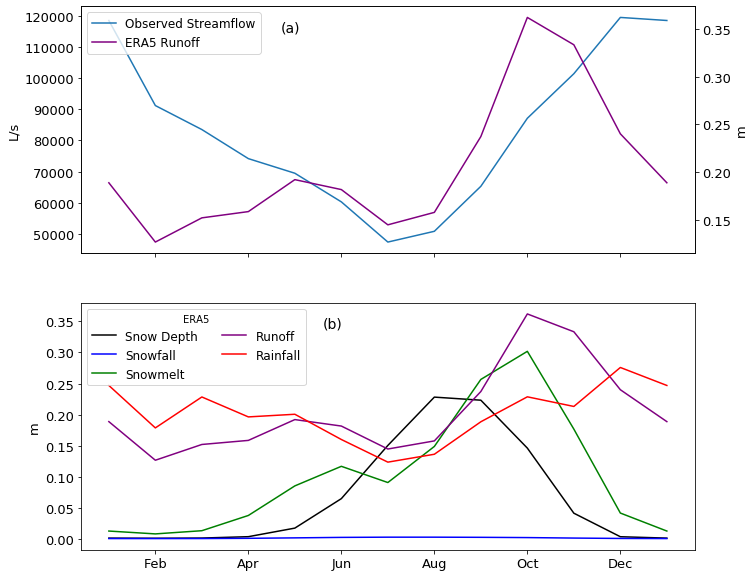

In [60]:
fig,axs = plt.subplots(2,1,figsize=(11,10),sharex=True)
axs = axs.flatten()

months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

axs[1].plot(months, era_sd.groupby(era_sd.time.dt.month).mean().values.tolist() + [era_sd.groupby(era_sd.time.dt.month).mean().values.tolist()[0]],label='Snow Depth',color='black')
axs[1].plot(months, era_sf.groupby(era_sf.time.dt.month).mean().values.tolist() + [era_sf.groupby(era_sf.time.dt.month).mean().values.tolist()[0]],color='blue',label='Snowfall')
axs[1].plot(months,(era_smlt * era_smlt.time.dt.daysinmonth).groupby(era_smlt.time.dt.month).mean().values.tolist() + [(era_smlt * era_smlt.time.dt.daysinmonth).groupby(era_smlt.time.dt.month).mean().values.tolist()[0]],color='green',label='Snowmelt')
axs[1].plot(months,(era_ro * era_ro.time.dt.daysinmonth).groupby(era_ro.time.dt.month).mean().values.tolist() + [(era_ro * era_ro.time.dt.daysinmonth).groupby(era_ro.time.dt.month).mean().values.tolist()[0]],color='purple',label='Runoff')

# rainfall, tp - sf
rf = ((era_tp * era_tp.time.dt.daysinmonth).groupby(era_tp.time.dt.month).mean() - (era_sf * era_sf.time.dt.daysinmonth).groupby(era_sf.time.dt.month).mean()).values.tolist()
axs[1].plot(months,rf + [rf[0]],color='red',label='Rainfall')

#monthly_flow_df[['71132','71123','71120','75292','71129','71135']].groupby(monthly_flow_df.index.month).mean().plot(ax=axs[2])
obs = monthly_flow_df[['71132','71123','71120','75292','71129','71135']].mean(axis=1).groupby(monthly_flow_df.index.month).mean().values.tolist()
obs_ln = axs[0].plot(months, obs + [obs[0]], label='Observed Streamflow')

ax2 = axs[0].twinx()
twin = ax2.plot(months,(era_ro * era_ro.time.dt.daysinmonth).groupby(era_ro.time.dt.month).mean().values.tolist() + [(era_ro * era_ro.time.dt.daysinmonth).groupby(era_ro.time.dt.month).mean().values.tolist()[0]],color='purple',label='ERA5 Runoff')
ax2.set_ylabel('m',fontsize=13)
#ax2.legend(loc='upper right')
axs[0].set_ylabel('L/s',color='black', fontsize=13)
#axs[1].legend(loc='upper left')
#labs = [l.get_label() for l in [obs_ln,twin]]

lines, labels = axs[0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax2.legend(lines + lines2, labels + labels2, loc=0, prop={'size': 12})

axs[1].set_ylabel('m',color='black',fontsize=13)
axs[1].set_title('')
axs[1].legend(loc='upper left',title='ERA5', ncol=2,prop={'size': 12})

axs[1].tick_params(axis='x',labelsize=13)
axs[1].tick_params(axis='y',labelsize=13)
axs[0].tick_params(axis='y',labelsize=13)
axs[0].tick_params(axis='x',labelsize=13)
ax2.tick_params(axis='y',labelsize=13)
ax2.tick_params(axis='x',labelsize=13)

axs[1].set_xticks([2,4,6,8,10,12],)
axs[1].set_xticklabels(['Feb','Apr','Jun','Aug','Oct','Dec'])

axs[0].text(4.7,115000,"(a)",fontsize=14)
axs[1].text(5.6,0.34,"(b)",fontsize=14)

plt.savefig('Figure9.png')


obs_ln.get_label

In [16]:
era_sd.groupby(era_sd.time.dt.month).mean().values.tolist() + [era_sd.groupby(era_sd.time.dt.month).mean().values.tolist()[0]]

[0.0008446617219653548,
 0.0006058788043841912,
 0.0009367266374835019,
 0.0031331533411460555,
 0.01695465622434364,
 0.06445946354601413,
 0.15019828756333475,
 0.22806791711524368,
 0.2231023495415772,
 0.1458774988821392,
 0.04099076512719196,
 0.003055874928349905,
 0.0008446617219653548]

In [121]:
(era_sf * era_sf.time.dt.daysinmonth)

<xarray.DataArray (time: 612)>
array([2.78106847e-03, 1.65362587e-04, 3.21788961e-03, 3.91303727e-02,
       1.00472620e-02, 3.50872335e-02, 8.89742673e-02, 8.84546825e-02,
       8.09725356e-02, 7.47204027e-02, 2.96718934e-03, 2.01038603e-03,
       8.03016456e-05, 1.09799474e-03, 3.85840547e-04, 5.80657822e-03,
       3.98178592e-03, 1.70861459e-02, 8.33526887e-02, 4.93496467e-02,
       1.09397471e-01, 2.88038860e-02, 1.73479222e-03, 2.11116175e-03,
       7.39749183e-04, 5.18490062e-05, 5.44243842e-03, 5.09663360e-03,
       1.16036456e-02, 4.72227994e-02, 2.99426630e-02, 5.57127181e-02,
       9.26351805e-02, 1.06806279e-01, 2.09890433e-02, 2.88947010e-05,
       8.29947699e-04, 4.02367007e-07, 4.48895748e-03, 1.37503740e-02,
       1.18839808e-01, 8.73352291e-02, 1.00280741e-01, 6.77912633e-02,
       8.20575812e-02, 6.41853707e-02, 2.91189462e-03, 1.94936959e-02,
       4.55197988e-03, 4.97424110e-07, 9.46407744e-04, 2.80721785e-02,
       1.01657821e-01, 7.95236526e-02, 2.19849226e-02, 1.37031962e-01,
       5.81862493e-02, 3.05053428e-02, 3.70791805e-02, 2.53500293e-03,
       6.23138529e-04, 2.81759257e-03, 9.10107530e-03, 9.19005843e-03,
       2.76160343e-02, 9.73921484e-02, 1.10608151e-01, 4.72825852e-02,
       4.32320535e-02, 8.81404915e-02, 4.61457560e-03, 1.13451821e-02,
       8.67472257e-04, 5.69109506e-04, 2.72899847e-03, 1.08599471e-02,
       2.75716493e-02, 3.65297029e-02, 8.99695698e-02, 1.13844547e-01,
       2.84153457e-02, 5.01402892e-02, 7.96783760e-03, 5.62781763e-03,
       1.59914481e-02, 1.32315345e-02, 8.28962362e-06, 1.33596080e-02,
       5.06792302e-02, 9.45152058e-02, 8.20665697e-02, 6.15495549e-02,
       2.54407647e-02, 8.49231832e-02, 2.35611990e-02, 1.42964061e-02,
       1.29321671e-02, 8.48812924e-04, 4.63999019e-05, 5.13154927e-02,
       3.52952081e-02, 1.01842126e-01, 6.22062979e-02, 5.89652109e-02,
       7.77459642e-02, 6.74702047e-02, 4.22685229e-02, 1.49140456e-02,
       6.86881714e-04, 6.51925802e-09, 8.78490008e-04, 7.39978163e-03,
       1.03430341e-02, 1.08251286e-02, 1.28088782e-01, 1.20162625e-01,
       7.69294435e-02, 5.99516681e-02, 7.49834261e-02, 9.66470709e-03,
       4.00932420e-04, 2.36262378e-03, 1.67536731e-02, 1.12488010e-02,
       2.88630978e-02, 1.56304445e-02, 6.34294870e-02, 6.08313077e-02,
       9.16750514e-02, 3.18029651e-02, 1.62307865e-03, 1.60524063e-02,
       9.23718724e-03, 7.22107753e-03, 3.46271505e-03, 3.51476577e-03,
       1.38279544e-02, 3.31379784e-02, 3.40183199e-02, 6.24382355e-02,
       9.67416541e-02, 2.21930548e-02, 4.44244875e-02, 1.44799163e-03,
       1.02071700e-04, 4.35091494e-05, 2.53458125e-04, 1.26764394e-02,
       2.05630831e-02, 3.60221728e-02, 8.61300131e-02, 1.92648226e-02,
       9.24967137e-02, 2.85790311e-02, 1.79672146e-03, 1.88465939e-02,
       1.13784735e-02, 1.34382567e-03, 3.70132481e-06, 8.56224334e-03,
       5.86739227e-02, 3.25749466e-02, 7.13995976e-02, 9.89691434e-02,
       5.77771778e-02, 9.26069934e-02, 6.18956747e-02, 1.46456940e-02,
       2.52099967e-02, 1.65641305e-03, 1.71602857e-02, 1.29959227e-02,
       3.77779665e-02, 8.06858282e-02, 4.57719141e-02, 4.90977006e-02,
       1.13235001e-01, 9.78232018e-03, 1.15892603e-02, 1.14981308e-02,
       2.94304226e-03, 6.75208867e-09, 3.95834604e-05, 2.23940123e-02,
       2.38930900e-02, 4.30241223e-02, 1.06217311e-01, 8.50648589e-02,
       3.76717490e-02, 7.39344889e-02, 1.88488663e-02, 6.38885504e-03,
       2.11403572e-04, 1.62532176e-04, 2.21718065e-03, 1.33493361e-02,
       2.16657108e-02, 1.00044410e-01, 9.16011906e-02, 1.01912622e-01,
       5.89768340e-02, 2.40334983e-02, 1.51097221e-02, 1.80858621e-03,
       2.73053508e-04, 5.04146264e-04, 9.41535958e-04, 5.21232711e-03,
       4.63972627e-02, 1.07542837e-01, 1.05478462e-01, 6.09425087e-02,
       5.02459591e-02, 1.28956598e-02, 1.54146553e-02, 3.80749415e-03,
       7.75046247e-03, 6.30428256e-03, 3.92456426e-03, 5.39565759e-03,
       1.77251261e-02, 7.26636498e-02, 5.16246567e-02, 3.4819360

In [122]:
era_sf

<xarray.DataArray 'sf' (time: 612)>
array([8.97118861e-05, 5.90580667e-06, 1.03802891e-04, 1.30434576e-03,
       3.24105225e-04, 1.16957445e-03, 2.87013765e-03, 2.85337686e-03,
       2.69908452e-03, 2.41033557e-03, 9.89063112e-05, 6.48511624e-05,
       2.59037566e-06, 3.92140977e-05, 1.24464692e-05, 1.93552607e-04,
       1.28444707e-04, 5.69538195e-04, 2.68879641e-03, 1.59192409e-03,
       3.64658237e-03, 9.29157613e-04, 5.78264075e-05, 6.81019920e-05,
       2.38628769e-05, 1.85175022e-06, 1.75562530e-04, 1.69887787e-04,
       3.74311147e-04, 1.57409331e-03, 9.65892355e-04, 1.79718446e-03,
       3.08783935e-03, 3.44536384e-03, 6.99634776e-04, 9.32087128e-07,
       2.67725064e-05, 1.38747244e-08, 1.44805080e-04, 4.58345799e-04,
       3.83354220e-03, 2.91117430e-03, 3.23486260e-03, 2.18681495e-03,
       2.73525271e-03, 2.07049583e-03, 9.70631539e-05, 6.28828901e-04,
       1.46838061e-04, 1.77651468e-08, 3.05292821e-05, 9.35739284e-04,
       3.27928454e-03, 2.65078842e-03, 7.09191050e-04, 4.42038589e-03,
       1.93954164e-03, 9.84043318e-04, 1.23597268e-03, 8.17742881e-05,
       2.01012429e-05, 1.00628306e-04, 2.93583074e-04, 3.06335281e-04,
       8.90839818e-04, 3.24640495e-03, 3.56800487e-03, 1.52524468e-03,
       1.44106845e-03, 2.84324166e-03, 1.53819187e-04, 3.65973615e-04,
       2.79829760e-05, 2.03253395e-05, 8.80322087e-05, 3.61998236e-04,
       8.89408041e-04, 1.21765676e-03, 2.90224419e-03, 3.67240473e-03,
       9.47178188e-04, 1.61742868e-03, 2.65594587e-04, 1.81542504e-04,
       5.15853163e-04, 4.56259809e-04, 2.67407213e-07, 4.45320267e-04,
       1.63481388e-03, 3.15050686e-03, 2.64730870e-03, 1.98546951e-03,
       8.48025491e-04, 2.73945752e-03, 7.85373302e-04, 4.61174390e-04,
       4.17166682e-04, 3.03147473e-05, 1.49677103e-06, 1.71051642e-03,
       1.13855510e-03, 3.39473754e-03, 2.00665477e-03, 1.90210358e-03,
       2.59153214e-03, 2.17645821e-03, 1.40895076e-03, 4.81098244e-04,
       2.21574746e-05, 2.32830644e-10, 2.83383874e-05, 2.46659388e-04,
       3.33646261e-04, 3.60837618e-04, 4.13189620e-03, 3.87621371e-03,
       2.56431478e-03, 1.93392478e-03, 2.49944754e-03, 3.11764745e-04,
       1.29333039e-05, 8.43794207e-05, 5.40441069e-04, 3.74960032e-04,
       9.31067670e-04, 5.21014817e-04, 2.04611248e-03, 1.96230025e-03,
       3.05583505e-03, 1.02590210e-03, 5.41026216e-05, 5.17819559e-04,
       2.97973782e-04, 2.49002673e-04, 1.11700485e-04, 1.17158859e-04,
       4.46063045e-04, 1.10459928e-03, 1.09736516e-03, 2.01413663e-03,
       3.22472180e-03, 7.15904994e-04, 1.48081625e-03, 4.67094073e-05,
       3.29263549e-06, 1.55389819e-06, 8.17606854e-06, 4.22547981e-04,
       6.63325261e-04, 1.20073909e-03, 2.77838752e-03, 6.21445890e-04,
       3.08322379e-03, 9.21904231e-04, 5.98907152e-05, 6.07954641e-04,
       3.67047534e-04, 4.79937741e-05, 1.19397575e-07, 2.85408111e-04,
       1.89270718e-03, 1.08583155e-03, 2.30321282e-03, 3.19255301e-03,
       1.92590593e-03, 2.98732237e-03, 2.06318916e-03, 4.72441741e-04,
       8.13225701e-04, 5.91576090e-05, 5.53557603e-04, 4.33197423e-04,
       1.21864408e-03, 2.68952761e-03, 1.47651336e-03, 1.58379679e-03,
       3.77450002e-03, 3.15558716e-04, 3.86308676e-04, 3.70907446e-04,
       9.49368470e-05, 2.32830644e-10, 1.27688582e-06, 7.46467077e-04,
       7.70744840e-04, 1.43413741e-03, 3.42636486e-03, 2.74402771e-03,
       1.25572497e-03, 2.38498351e-03, 6.28295543e-04, 2.06092098e-04,
       6.81947008e-06, 5.80472057e-06, 7.15219566e-05, 4.44977871e-04,
       6.98893895e-04, 3.33481368e-03, 2.95487712e-03, 3.28750393e-03,
       1.96589447e-03, 7.75274138e-04, 5.03657403e-04, 5.83414908e-05,
       8.80817766e-06, 1.80052237e-05, 3.03721277e-05, 1.73744237e-04,
       1.49668589e-03, 3.58476124e-03, 3.40253102e-03, 1.96588738e-03,
       1.67486530e-03, 4.15989025e-04, 5.13821845e-04, 1.22822392e-04,
       2.50014918e-04, 2.25152948e-04, 1.26598847e-04, 1.79855253e-04,
       5.71778262e-04, 2.42212166e-03, 1.66531151e-03, 1.12

In [115]:
era_smlt.groupby(era_smlt.time.dt.month).mean()

<xarray.DataArray 'smlt' (month: 12, latitude: 610, longitude: 610)>
array([[[9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        ...,
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10]],

       [[9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        ...,
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10]],

       [[9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        ...,
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10]],

       ...,

       [[9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        ...,
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10]],

       [[9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        ...,
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10]],

       [[9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
        [9.31322575e-10, 9.31322575e-10, 9.31322575e-10, ...,
         9.31322575e-10, 9.31322575e-10, 9.31322575e-10],
   

In [116]:
era_sf

<xarray.DataArray 'sf' (time: 612)>
array([8.97118861e-05, 5.90580667e-06, 1.03802891e-04, 1.30434576e-03,
       3.24105225e-04, 1.16957445e-03, 2.87013765e-03, 2.85337686e-03,
       2.69908452e-03, 2.41033557e-03, 9.89063112e-05, 6.48511624e-05,
       2.59037566e-06, 3.92140977e-05, 1.24464692e-05, 1.93552607e-04,
       1.28444707e-04, 5.69538195e-04, 2.68879641e-03, 1.59192409e-03,
       3.64658237e-03, 9.29157613e-04, 5.78264075e-05, 6.81019920e-05,
       2.38628769e-05, 1.85175022e-06, 1.75562530e-04, 1.69887787e-04,
       3.74311147e-04, 1.57409331e-03, 9.65892355e-04, 1.79718446e-03,
       3.08783935e-03, 3.44536384e-03, 6.99634776e-04, 9.32087128e-07,
       2.67725064e-05, 1.38747244e-08, 1.44805080e-04, 4.58345799e-04,
       3.83354220e-03, 2.91117430e-03, 3.23486260e-03, 2.18681495e-03,
       2.73525271e-03, 2.07049583e-03, 9.70631539e-05, 6.28828901e-04,
       1.46838061e-04, 1.77651468e-08, 3.05292821e-05, 9.35739284e-04,
       3.27928454e-03, 2.65078842e-03, 7.09191050e-04, 4.42038589e-03,
       1.93954164e-03, 9.84043318e-04, 1.23597268e-03, 8.17742881e-05,
       2.01012429e-05, 1.00628306e-04, 2.93583074e-04, 3.06335281e-04,
       8.90839818e-04, 3.24640495e-03, 3.56800487e-03, 1.52524468e-03,
       1.44106845e-03, 2.84324166e-03, 1.53819187e-04, 3.65973615e-04,
       2.79829760e-05, 2.03253395e-05, 8.80322087e-05, 3.61998236e-04,
       8.89408041e-04, 1.21765676e-03, 2.90224419e-03, 3.67240473e-03,
       9.47178188e-04, 1.61742868e-03, 2.65594587e-04, 1.81542504e-04,
       5.15853163e-04, 4.56259809e-04, 2.67407213e-07, 4.45320267e-04,
       1.63481388e-03, 3.15050686e-03, 2.64730870e-03, 1.98546951e-03,
       8.48025491e-04, 2.73945752e-03, 7.85373302e-04, 4.61174390e-04,
       4.17166682e-04, 3.03147473e-05, 1.49677103e-06, 1.71051642e-03,
       1.13855510e-03, 3.39473754e-03, 2.00665477e-03, 1.90210358e-03,
       2.59153214e-03, 2.17645821e-03, 1.40895076e-03, 4.81098244e-04,
       2.21574746e-05, 2.32830644e-10, 2.83383874e-05, 2.46659388e-04,
       3.33646261e-04, 3.60837618e-04, 4.13189620e-03, 3.87621371e-03,
       2.56431478e-03, 1.93392478e-03, 2.49944754e-03, 3.11764745e-04,
       1.29333039e-05, 8.43794207e-05, 5.40441069e-04, 3.74960032e-04,
       9.31067670e-04, 5.21014817e-04, 2.04611248e-03, 1.96230025e-03,
       3.05583505e-03, 1.02590210e-03, 5.41026216e-05, 5.17819559e-04,
       2.97973782e-04, 2.49002673e-04, 1.11700485e-04, 1.17158859e-04,
       4.46063045e-04, 1.10459928e-03, 1.09736516e-03, 2.01413663e-03,
       3.22472180e-03, 7.15904994e-04, 1.48081625e-03, 4.67094073e-05,
       3.29263549e-06, 1.55389819e-06, 8.17606854e-06, 4.22547981e-04,
       6.63325261e-04, 1.20073909e-03, 2.77838752e-03, 6.21445890e-04,
       3.08322379e-03, 9.21904231e-04, 5.98907152e-05, 6.07954641e-04,
       3.67047534e-04, 4.79937741e-05, 1.19397575e-07, 2.85408111e-04,
       1.89270718e-03, 1.08583155e-03, 2.30321282e-03, 3.19255301e-03,
       1.92590593e-03, 2.98732237e-03, 2.06318916e-03, 4.72441741e-04,
       8.13225701e-04, 5.91576090e-05, 5.53557603e-04, 4.33197423e-04,
       1.21864408e-03, 2.68952761e-03, 1.47651336e-03, 1.58379679e-03,
       3.77450002e-03, 3.15558716e-04, 3.86308676e-04, 3.70907446e-04,
       9.49368470e-05, 2.32830644e-10, 1.27688582e-06, 7.46467077e-04,
       7.70744840e-04, 1.43413741e-03, 3.42636486e-03, 2.74402771e-03,
       1.25572497e-03, 2.38498351e-03, 6.28295543e-04, 2.06092098e-04,
       6.81947008e-06, 5.80472057e-06, 7.15219566e-05, 4.44977871e-04,
       6.98893895e-04, 3.33481368e-03, 2.95487712e-03, 3.28750393e-03,
       1.96589447e-03, 7.75274138e-04, 5.03657403e-04, 5.83414908e-05,
       8.80817766e-06, 1.80052237e-05, 3.03721277e-05, 1.73744237e-04,
       1.49668589e-03, 3.58476124e-03, 3.40253102e-03, 1.96588738e-03,
       1.67486530e-03, 4.15989025e-04, 5.13821845e-04, 1.22822392e-04,
       2.50014918e-04, 2.25152948e-04, 1.26598847e-04, 1.79855253e-04,
       5.71778262e-04, 2.42212166e-03, 1.66531151e-03, 1.12

In [110]:
grouped.month.dt.daysinmonth

TypeError: '.dt' accessor only available for DataArray with datetime64 timedelta64 dtype or for arrays containing cftime datetime objects.

In [101]:
era_sf.groupby(era_sf.time.dt.month).mean().values

1.99931168e-03 * 30

0.0599793504

In [27]:
era_sf.sel(time=era_smlt.time.dt.month.isin([6])).plot(label='june sf')
era_smlt.sel(time=era_smlt.time.dt.month.isin([6])).plot(label='june smlt')

plt.legend()

KeyboardInterrupt: 

In [26]:
len(ob_flow[ob_flow.index.month == 9])

51

In [24]:
len(clipped_era.sel(time=clipped_era.time.dt.month.isin([11])))

51

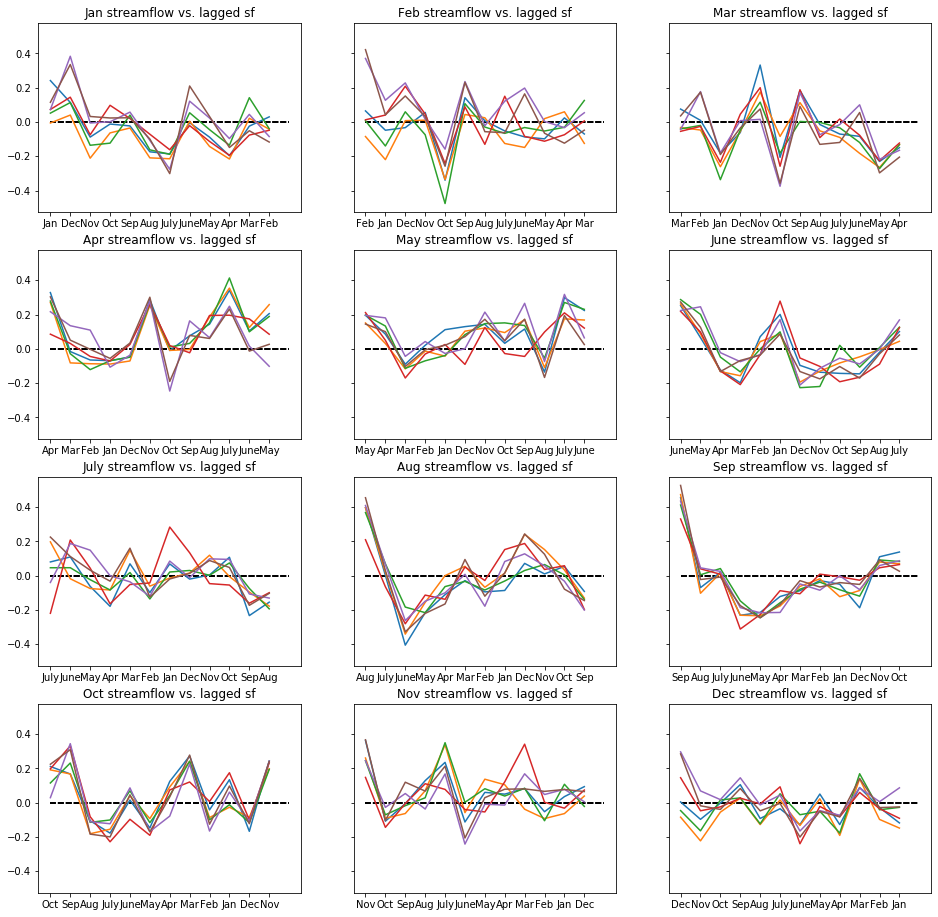

In [5]:
from scipy import stats

fig, axs = plt.subplots(4,3,figsize=(16,16),sharey=True)
axs = axs.flatten()

month_dict = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'June',7:'July',8:'Aug',
               9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

index = 'sf'
era_da = monthly_era_interp[index].rio.write_crs("EPSG:4326")
era_da.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

for i,ax in enumerate(axs):
    
    month = i+1
        
    for site in ['71120','71123','71132','75292','71129','71135']:

        ob_flow = monthly_flow_df[site]
        ob_month = ob_flow[ob_flow.index.month == month]
        detrended_obs = detrend(ob_month)

        catchment_geo = catchment_data.loc[[float(site)]]

        clipped = era_da.rio.clip(catchment_geo.geometry,catchment_data.crs)
        clipped_era = clipped.mean(['longitude','latitude'])

        vals = []
        comp_months = []
        for j in range(12):
            if j >= month:
                comp_month = 12 - (j - month)
                comp_month_ts = clipped_era.sel(time=clipped_era.time.dt.month.isin([comp_month])).values.tolist()
                
                comp_month_ts = [np.mean(comp_month_ts)] + comp_month_ts
                comp_month_ts = comp_month_ts[:-1]

            else:
                comp_month = month - j
                comp_month_ts = clipped_era.sel(time=clipped_era.time.dt.month.isin([comp_month])).values.tolist()
                #print('here2')
                #print(comp_month)
                #print(ERA5_df)
                #print(ERA5_month)
                
            #print(str(month) + 'v ' + str(comp_month))
            #print(str(ob_month.index.year[0]) + " " +  str(ob_month.index.month[0]))
            #print(str(ERA5_month.index.year[0]) + " " +  str(ERA5_month.index.month[0]))
            
            (r,p) = stats.pearsonr(detrended_obs,comp_month_ts)

            comp_months.append(month_dict[comp_month])
            vals.append(r)

        ax.plot(vals)
        ax.set_xticks([j for j in range(len(vals))])
        ax.set_xticklabels(comp_months)
        ax.hlines(0,0,12,'black','dashed')

    ax.set_title(month_dict[month] + " streamflow vs. lagged " + index)

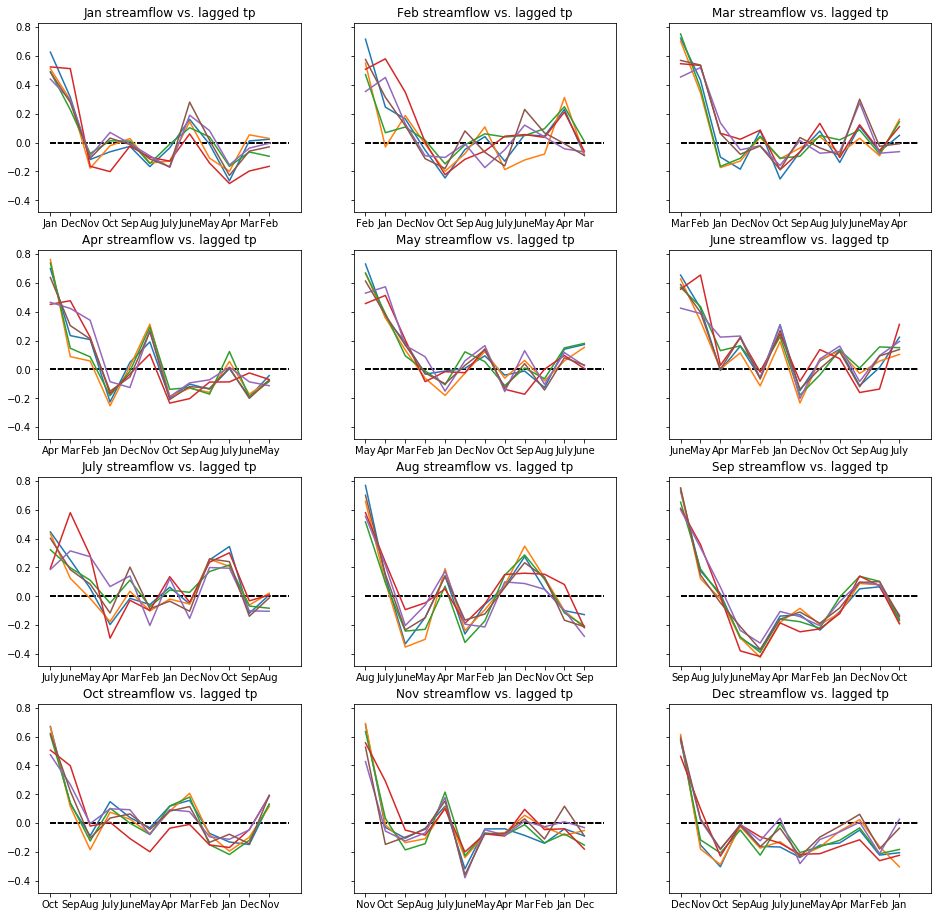

In [6]:
from scipy import stats

fig, axs = plt.subplots(4,3,figsize=(16,16),sharey=True)
axs = axs.flatten()

month_dict = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'June',7:'July',8:'Aug',
               9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

index = 'tp'
era_da = monthly_era_interp[index].rio.write_crs("EPSG:4326")
era_da.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

for i,ax in enumerate(axs):
    
    month = i+1
        
    for site in ['71120','71123','71132','75292','71129','71135']:

        ob_flow = monthly_flow_df[site]
        ob_month = ob_flow[ob_flow.index.month == month]
        detrended_obs = detrend(ob_month)

        catchment_geo = catchment_data.loc[[float(site)]]

        clipped = era_da.rio.clip(catchment_geo.geometry,catchment_data.crs)
        clipped_era = clipped.mean(['longitude','latitude'])

        vals = []
        comp_months = []
        for j in range(12):
            if j >= month:
                comp_month = 12 - (j - month)
                comp_month_ts = clipped_era.sel(time=clipped_era.time.dt.month.isin([comp_month])).values.tolist()
                
                comp_month_ts = [np.mean(comp_month_ts)] + comp_month_ts
                comp_month_ts = comp_month_ts[:-1]

            else:
                comp_month = month - j
                comp_month_ts = clipped_era.sel(time=clipped_era.time.dt.month.isin([comp_month])).values.tolist()
                #print('here2')
                #print(comp_month)
                #print(ERA5_df)
                #print(ERA5_month)
                
            #print(str(month) + 'v ' + str(comp_month))
            #print(str(ob_month.index.year[0]) + " " +  str(ob_month.index.month[0]))
            #print(str(ERA5_month.index.year[0]) + " " +  str(ERA5_month.index.month[0]))
            
            (r,p) = stats.pearsonr(detrended_obs,comp_month_ts)

            comp_months.append(month_dict[comp_month])
            vals.append(r)

        ax.plot(vals)
        ax.set_xticks([j for j in range(len(vals))])
        ax.set_xticklabels(comp_months)
        ax.hlines(0,0,12,'black','dashed')

    ax.set_title(month_dict[month] + " streamflow vs. lagged " + index)

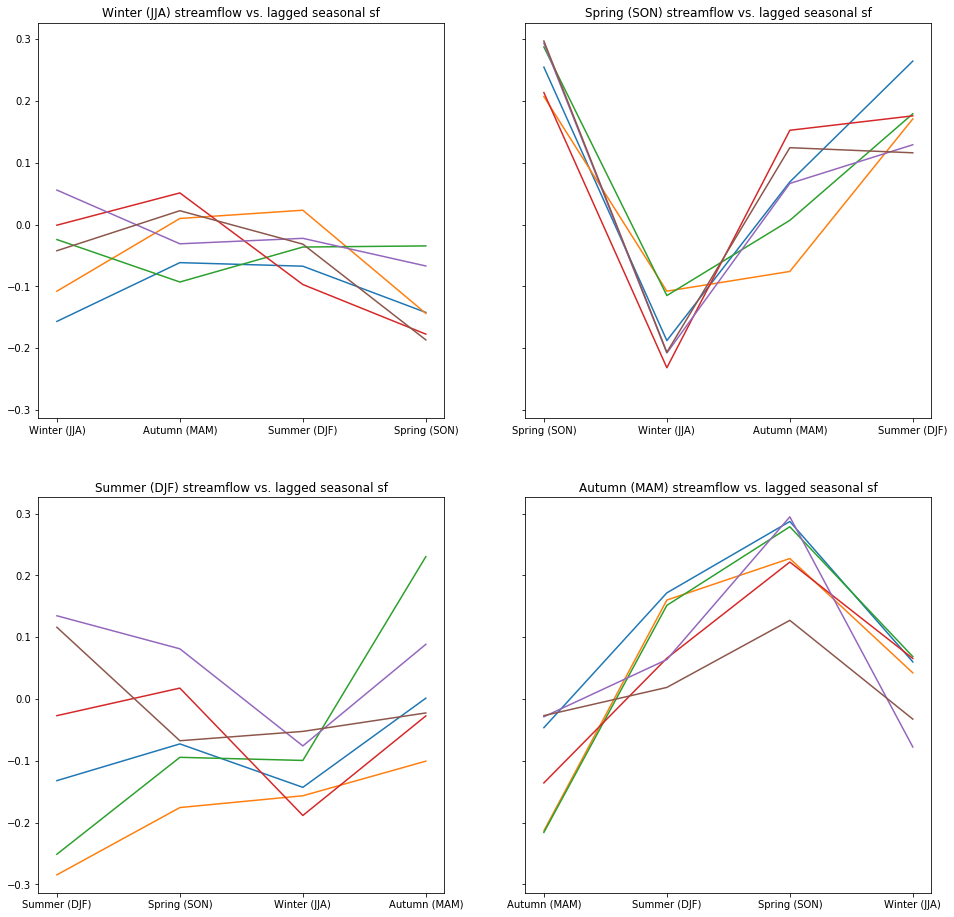

In [11]:
from scipy import stats

fig, axs = plt.subplots(2,2,figsize=(16,16),sharey=True)
axs = axs.flatten()

season_dict = {6:"Winter (JJA)",9:'Spring (SON)',12:'Summer (DJF)',3:"Autumn (MAM)"}

comp_dict = {12:[12,9,6,3],
             9: [9,6,3,12],
             6: [6,3,12,9],
             3: [3,12,9,6]}

index = 'sf'
era_index = seasonal_era_interp[index].rio.write_crs("EPSG:4326")
era_index.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

for i,s in enumerate([6,9,12,3]):
    
    flow_season = seasonal_flow_df[seasonal_flow_df.index.month == s]
    
    for site in ['71120','71123','71132','75292','71129','71135']:

        detrended_flow = detrend(flow_season[site])

        catchment_geo = catchment_data.loc[[float(site)]]
        
        #print(catchment_geo)

        clipped_era = era_index.rio.clip(catchment_geo.geometry,catchment_data.crs).mean(['longitude','latitude'])

        vals = []
        comp_seasons = []
        for j in range(4):
            comp_season = comp_dict[s][j]
            #print(s)
            #print(comp_season)
            
            comp_season_ts = clipped_era.sel(time=clipped_era.time.dt.month.isin([comp_season])).values.tolist()

            if comp_season > s:
                comp_season_ts = [np.mean(comp_season_ts)] + comp_season_ts
                comp_season_ts = comp_season_ts[:-1]
                
            #print(flow_season[site])
            #print(clipped_era.sel(time=clipped_era.time.dt.month.isin([comp_season])))
            
            (r,p) = stats.pearsonr(detrended_flow,comp_season_ts)
            
            #if comp_season == s:
            #    print(site + ' ' + str(s) + ": " + str(r))
                
            #print(site + " " + str(s) + "v" + str(comp_season))
            #print(r)
            comp_seasons.append(season_dict[comp_season])
            vals.append(r)

        axs[i].plot(vals)
        axs[i].set_xticks([k for k in range(len(vals))])
        axs[i].set_xticklabels(comp_seasons)

    axs[i].set_title(season_dict[s] + " streamflow vs. lagged seasonal " + index)

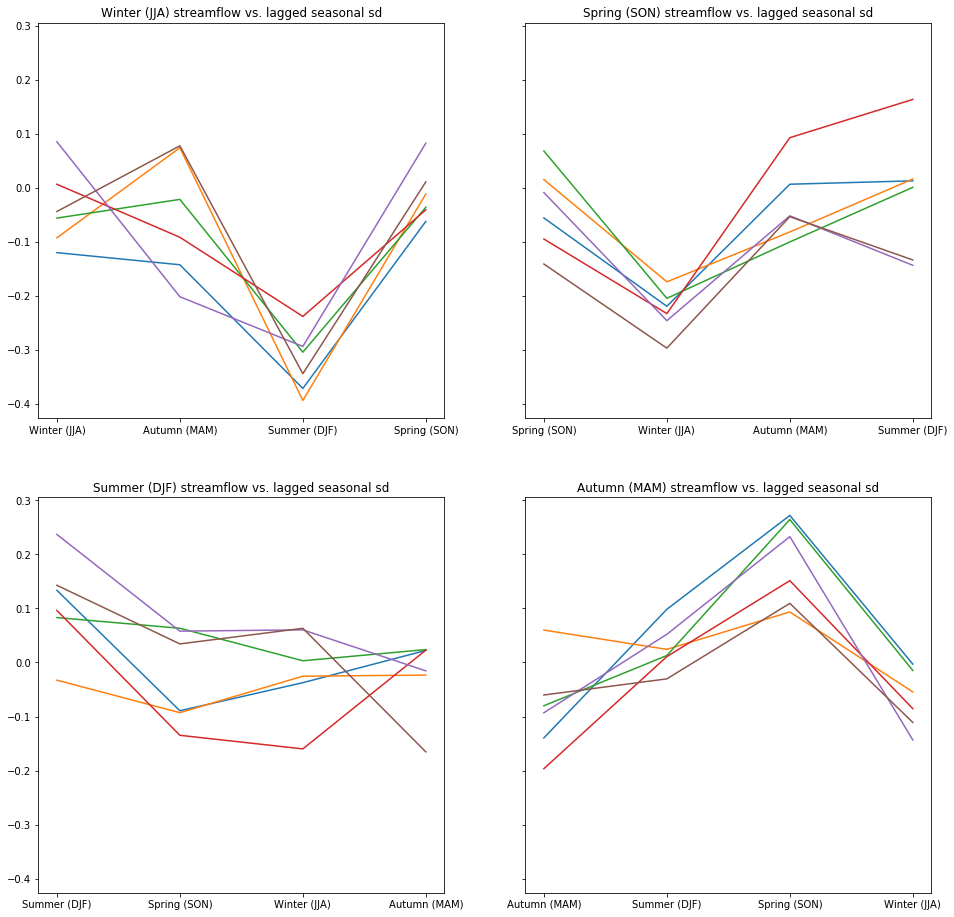

In [12]:
from scipy import stats

fig, axs = plt.subplots(2,2,figsize=(16,16),sharey=True)
axs = axs.flatten()

season_dict = {6:"Winter (JJA)",9:'Spring (SON)',12:'Summer (DJF)',3:"Autumn (MAM)"}

comp_dict = {12:[12,9,6,3],
             9: [9,6,3,12],
             6: [6,3,12,9],
             3: [3,12,9,6]}

index = 'sd'
era_index = seasonal_era_interp[index].rio.write_crs("EPSG:4326")
era_index.rio.set_spatial_dims('longitude', 'latitude', inplace=True)

for i,s in enumerate([6,9,12,3]):
    
    flow_season = seasonal_flow_df[seasonal_flow_df.index.month == s]
    
    for site in ['71120','71123','71132','75292','71129','71135']:

        detrended_flow = detrend(flow_season[site])

        catchment_geo = catchment_data.loc[[float(site)]]
        
        #print(catchment_geo)

        clipped_era = era_index.rio.clip(catchment_geo.geometry,catchment_data.crs).mean(['longitude','latitude'])

        vals = []
        comp_seasons = []
        for j in range(4):
            comp_season = comp_dict[s][j]
            #print(s)
            #print(comp_season)
            
            comp_season_ts = clipped_era.sel(time=clipped_era.time.dt.month.isin([comp_season])).values.tolist()

            if comp_season > s:
                comp_season_ts = [np.mean(comp_season_ts)] + comp_season_ts
                comp_season_ts = comp_season_ts[:-1]
                
            #print(flow_season[site])
            #print(clipped_era.sel(time=clipped_era.time.dt.month.isin([comp_season])))
            
            (r,p) = stats.pearsonr(detrended_flow,comp_season_ts)
            
            #if comp_season == s:
            #    print(site + ' ' + str(s) + ": " + str(r))
                
            #print(site + " " + str(s) + "v" + str(comp_season))
            #print(r)
            comp_seasons.append(season_dict[comp_season])
            vals.append(r)

        axs[i].plot(vals)
        axs[i].set_xticks([k for k in range(len(vals))])
        axs[i].set_xticklabels(comp_seasons)

    axs[i].set_title(season_dict[s] + " streamflow vs. lagged seasonal " + index)

In [8]:
test2

[2.0, 1, 2, 3]